In [1]:
%pip install -q --no-deps "transformer_lens<3"
%pip install -q "transformers>=4.44,<5" einops fancy_einsum jaxtyping beartype rich better-abc accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.9/239.9 kB 5.0 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 90.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformer-lens 2.18.0 requires transformers-stream-generator<0.0.6,>=0.0.5, which is not installed.
transformer-lens 2.18.0 requires beartype<0.15.0,>=0.14.1, but you have beartype 0.22.9 which is incompatible.
transformer-lens 2.18.0 requires numpy<2,>=1.26; python_version == "3.12", but you have numpy 2.0.2 which is incompatible.
Note: you m

### Note: You need to restart the kernel after running the above cell
Run this cell once per session, then restart the kernel before running anything else. The restart is required because the interpreter has already loaded the pre-installed versions of these packages; pip replacing them on disk doesn't change what's in memory. After restarting, skip this cell and continue from the next one — but do run it again at the start of any new session.

In [1]:
import numpy, transformers, transformer_lens
import importlib.metadata as md
print(numpy.__version__, transformers.__version__, md.version("transformer_lens"))

2.0.2 4.57.6 2.18.0


In [2]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))
x = torch.randn(1000, 1000, device="cuda", dtype=torch.bfloat16)
print((x @ x).sum().item())

True Tesla T4
10752.0


In [3]:
import os, getpass
from pathlib import Path

os.environ["HF_HOME"]  = "/tmp/hf"
os.environ["HF_TOKEN"] = getpass.getpass("HF token: ")

OUT = Path(os.environ.get("OUT_DIR", "/kaggle/working"))
OUT.mkdir(parents=True, exist_ok=True)
print("results ->", OUT)

results -> /kaggle/working


In [4]:
from transformer_lens import HookedTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL  = "google/gemma-2-2b"

model = HookedTransformer.from_pretrained(MODEL, device=device, dtype=torch.bfloat16)
model.eval()
print(device, model.cfg.n_layers, model.cfg.d_model, model.cfg.output_logits_soft_cap)

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
cuda 26 2304 30.0


In [5]:
WORDS = [
    # (japanese, english, german)
    ("花",   "flower",   "Blume"),
    ("犬",   "dog",      "Hund"),
    ("山",   "mountain", "Berg"),
    ("水",   "water",    "Wasser"),
    ("本",   "book",     "Buch"),
    ("家",   "house",    "Haus"),
    ("月",   "moon",     "Mond"),
    ("魚",   "fish",     "Fisch"),
    ("鳥",   "bird",     "Vogel"),
    ("木",   "tree",     "Baum"),
    ("目",   "eye",      "Auge"),
    ("車",   "car",      "Auto"),
    ("王",   "king",     "König"),
    ("雪",   "snow",     "Schnee"),
    ("塩",   "salt",     "Salz"),
    ("石",   "stone",    "Stein"),
    ("血",   "blood",    "Blut"),
    ("卵",   "egg",      "Ei"),
    ("靴",   "shoe",     "Schuh"),
    ("船",   "ship",     "Schiff"),
    ("夏",   "summer",   "Sommer"),
    ("銀",   "silver",   "Silber"),
    ("道",   "road",     "Straße"),
    ("空",   "sky",      "Himmel"),
    ("火",   "fire",     "Feuer"),
    ("星",   "star",     "Stern"),
    ("海",   "sea",      "Meer"),
    ("川",   "river",    "Fluss"),
    ("雨",   "rain",     "Regen"),
    ("足",   "foot",     "Fuß"),
    ("頭",   "head",     "Kopf"),
    ("口",   "mouth",    "Mund"),
    ("耳",   "ear",      "Ohr"),
    ("歯",   "tooth",    "Zahn"),
    ("肉",   "meat",     "Fleisch"),
    ("米",   "rice",     "Reis"),
    ("茶",   "tea",      "Tee"),
    ("鉄",   "iron",     "Eisen"),
    ("紙",   "paper",    "Papier"),
    ("窓",   "window",   "Fenster"),
    ("橋",   "bridge",   "Brücke"),
    ("島",   "island",   "Insel"),
    ("氷",   "ice",      "Eis"),
    ("光",   "light",    "Licht"),
    ("色",   "color",    "Farbe"),
    ("声",   "voice",    "Stimme"),
    ("骨",   "bone",     "Knochen"),
    ("顔",   "face",     "Gesicht"),
    ("髪",   "hair",     "Haar"),
    ("馬",   "horse",    "Pferd"),
    ("牛",   "cow",      "Kuh"),
    ("猫",   "cat",      "Katze"),
    ("雲",   "cloud",    "Wolke"),
    ("森",   "forest",   "Wald"),
]
print(len(WORDS), "triples")

54 triples


In [6]:
import random

def make_prompt(target_ja, examples, n_shot=4, seed=0):
    """JA -> DE translation."""
    rng = random.Random(seed)
    shots = rng.sample([e for e in examples if e[0] != target_ja], n_shot)
    lines = [f"日本語: {ja} - ドイツ語: {de}" for ja, en, de in shots]
    lines.append(f"日本語: {target_ja} - ドイツ語:")
    return "\n".join(lines)

def make_repeat_prompt(target_ja, examples, n_shot=4, seed=0):
    """JA -> JA repetition control."""
    rng = random.Random(seed)
    shots = rng.sample([e for e in examples if e[0] != target_ja], n_shot)
    lines = [f"日本語: {ja} - 日本語: {ja}" for ja, en, de in shots]
    lines.append(f"日本語: {target_ja} - 日本語:")
    return "\n".join(lines)

print(make_prompt("花", WORDS))
print("---")
print(make_repeat_prompt("花", WORDS))

日本語: 星 - ドイツ語: Stern
日本語: 馬 - ドイツ語: Pferd
日本語: 川 - ドイツ語: Fluss
日本語: 水 - ドイツ語: Wasser
日本語: 花 - ドイツ語:
---
日本語: 星 - 日本語: 星
日本語: 馬 - 日本語: 馬
日本語: 川 - 日本語: 川
日本語: 水 - 日本語: 水
日本語: 花 - 日本語:


In [7]:
# Build the decoded vocabulary once. SentencePiece marks a leading space as U+2581.
_vocab_toks = model.tokenizer.convert_ids_to_tokens(list(range(model.cfg.d_vocab)))
VOCAB_STRS  = [t.replace("▁", " ") if isinstance(t, str) else "" for t in _vocab_toks]

def start_token_ids(model, word):
    """Every vocab token that could begin `word` (Wendler et al., Appendix A.2)."""
    ids = set()

    # (a) first token of the canonical tokenization, spaced and unspaced.
    #     Catches byte-fallback tokens, which are not string prefixes.
    for s in (word, " " + word):
        toks = model.to_tokens(s, prepend_bos=False)[0]
        if len(toks):
            ids.add(toks[0].item())

    # (b) every vocab token that is a string prefix of the word.
    #     This is the part that catches ' Bl' alongside ' Blume'.
    spaced = " " + word
    for i, vs in enumerate(VOCAB_STRS):
        if vs.strip() and (word.startswith(vs) or spaced.startswith(vs)):
            ids.add(i)

    return ids

# Make the space bug visible:
print("bare  花 ->", model.to_str_tokens("花",  prepend_bos=False))
print("space 花 ->", model.to_str_tokens(" 花", prepend_bos=False))

# Show what prefix summation adds over first-token-only scoring:
for w in ("Blume", "flower", "花"):
    first = {model.to_tokens(s, prepend_bos=False)[0][0].item() for s in (w, " " + w)}
    full  = start_token_ids(model, w)
    print(f"{w:8} first-token {len(first)} -> full {len(full)}; "
          f"added {[repr(VOCAB_STRS[i]) for i in sorted(full - first)][:8]}")

bare  花 -> ['花']
space 花 -> [' 花']
Blume    first-token 2 -> full 8; added ["' B'", "' Bl'", "'Bl'", "' Blu'", "' Blum'", "'B'"]
flower   first-token 2 -> full 10; added ["' f'", "' flo'", "'flo'", "' flow'", "'fl'", "'flow'", "' fl'", "'f'"]
花        first-token 2 -> full 2; added []


In [8]:
from collections import Counter

def n_tokens(model, word, space=True):
    s = (" " + word) if space else word
    return len(model.to_str_tokens(s, prepend_bos=False))

for lang, i in [("Japanese", 0), ("English", 1), ("German", 2)]:
    counts = Counter(n_tokens(model, w[i]) for w in WORDS)
    single = counts.get(1, 0)
    print(f"{lang:9} single-token {single:2}/{len(WORDS)} = {single/len(WORDS):4.0%}   lengths {dict(sorted(counts.items()))}")

Japanese  single-token 53/54 =  98%   lengths {1: 53, 2: 1}
English   single-token 54/54 = 100%   lengths {1: 54}
German    single-token 53/54 =  98%   lengths {1: 53, 2: 1}


In [9]:
clean, dropped = [], []
for ja, en, de in WORDS:
    S = {"ja": start_token_ids(model, ja),
         "en": start_token_ids(model, en),
         "de": start_token_ids(model, de)}
    clash = [(a, b) for a in S for b in S if a < b and S[a] & S[b]]
    if clash:
        dropped.append((ja, en, de, clash))
    else:
        clean.append((ja, en, de, sorted(S["ja"]), sorted(S["en"]), sorted(S["de"])))

print(f"{len(clean)}/{len(WORDS)} usable triples")
for ja, en, de, clash in dropped:
    print(f"  dropped {ja} / {en} / {de} — overlapping sets {clash}")

# Stale-state guard. Redefining start_token_ids does NOT rebuild `clean`: the
# sweep would run cleanly against the previous scoring with no traceback. Under
# prefix summation the European words must have more than one id each; length 1
# means this cell ran against first-token-only scoring and every result below
# is stale. Assert rather than print — this class of bug fails silently.
n_ids = [len(x) for x in clean[0][3:6]]
print("ids per language in clean[0] (ja, en, de):", n_ids)
assert max(n_ids[1:]) > 1, "first-token-only ids — re-run the start_token_ids cell, then this one"

54/54 usable triples
ids per language in clean[0] (ja, en, de): [2, 10, 8]


In [10]:
import gc

def lens_probs(model, prompt, id_sets):
    """Logit lens. Returns (probs [n_rows, n_sets], labels).

    Wendler et al. §3.2 define the lens as treating an intermediate latent "as if
    it were a final-layer latent" -- so each latent gets the model's OWN final
    norm, computed from that latent, then the model's own unembedding.

    cache.apply_ln_to_stack() is deliberately NOT used here. That helper scales
    every component by the *final* layer's cached scale so contributions sum
    linearly to the real logits -- correct for logit attribution, wrong for a
    lens, because an intermediate latent then carries a normalisation that has
    nothing to do with it. The final row is identical either way, which is why a
    verification that only checks the last row cannot detect the difference.
    """
    with torch.no_grad():
        _, cache = model.run_with_cache(prompt)
        resid, labels = cache.accumulated_resid(layer=-1, incl_mid=False, return_labels=True)
        h = resid[:, 0, -1, :].unsqueeze(0)          # [1, n_rows, d_model], un-normalised
        del cache

        h = model.ln_final(h)                        # per-latent, not a cached scale

        # Wendler §3.1: RMS normalisation places every latent on a hypersphere of
        # radius sqrt(d). Architecture-independent, and it fails loudly if the
        # normalisation path is wrong for this model family. (Assumes fold_ln=True,
        # the from_pretrained default, so ln_final applies scale without weights.)
        radius = h[0].norm(dim=-1) / model.cfg.d_model ** 0.5
        assert (radius - 1).abs().max() < 0.05, (
            f"post-norm radius {radius.min():.3f}-{radius.max():.3f}, expected 1.0 "
            f"-- the final norm is not being applied correctly for {model.cfg.model_name}")

        lg = model.unembed(h)[0].float()             # z = U h, includes b_U

        # Gemma-2 soft-caps logits inside forward(); model.unembed bypasses that
        # path. Llama has no cap, getattr returns None, and this is a no-op.
        cap = getattr(model.cfg, "output_logits_soft_cap", None)
        if cap:
            lg = cap * torch.tanh(lg / cap)

        p = lg.softmax(-1)
        out = torch.stack([p[:, list(ids)].sum(-1) for ids in id_sets], dim=-1).cpu()

    gc.collect(); torch.cuda.empty_cache()
    return out, labels

In [11]:
ja, en, de, ja_ids, en_ids, de_ids = clean[0]
prompt   = make_prompt(ja, WORDS)
id_sets  = [ja_ids, en_ids, de_ids]

probs, labels = lens_probs(model, prompt, id_sets)

real_full = model(prompt)[0, -1].float().softmax(-1)
real = torch.tensor([real_full[list(s)].sum().item() for s in id_sets])

print("lens final:", [f"{v:.4f}" for v in probs[-1].tolist()])
print("model     :", [f"{v:.4f}" for v in real.tolist()])
assert torch.allclose(probs[-1], real, rtol=0.05, atol=1e-4), (probs[-1], real)
print("lens verified")
print(f"{len(labels)} rows;", labels[:3], "...", labels[-2:])

# The assertion above only covers the LAST row, where the lens and the model see
# the same latent. Intermediate rows -- which is where every result in this
# project lives -- are checked by the sqrt(d) invariant inside lens_probs, and
# spot-checked here so the numbers are visible rather than merely asserted.
with torch.no_grad():
    _, cache = model.run_with_cache(prompt)
    r, _ = cache.accumulated_resid(layer=-1, incl_mid=False, return_labels=True)
    h = model.ln_final(r[:, 0, -1, :].unsqueeze(0))[0]
    del cache
rad = (h.norm(dim=-1) / model.cfg.d_model ** 0.5).float()
print(f"post-norm radius / sqrt(d): min {rad.min():.4f}  max {rad.max():.4f}  (expect 1.0)")

lens final: ['0.0000', '0.0000', '0.6849']
model     : ['0.0000', '0.0000', '0.6885']
lens verified
27 rows; ['0_pre', '1_pre', '2_pre'] ... ['25_pre', 'final_post']
post-norm radius / sqrt(d): min 1.0000  max 1.0000  (expect 1.0)


In [12]:
# Is the lens/model gap bf16 rounding, or a systematic path difference?
# Uses the SAME normalisation path as lens_probs, so this diagnoses the lens we
# actually run rather than a different one.
with torch.no_grad():
    _, cache = model.run_with_cache(prompt)
    r, labels = cache.accumulated_resid(layer=-1, incl_mid=False, return_labels=True)
    h = model.ln_final(r[:, 0, -1, :].unsqueeze(0))
    del cache
    lens_lg = model.unembed(h)[0][-1].float()
    cap = getattr(model.cfg, "output_logits_soft_cap", None)
    if cap:
        lens_lg = cap * torch.tanh(lens_lg / cap)
    real_lg = model(prompt)[0, -1].float()

d = lens_lg - real_lg
print("max |Δlogit| :", d.abs().max().item())
print("mean Δlogit  :", d.mean().item())
print("top-5 lens   :", [model.to_string(t) for t in lens_lg.topk(5).indices])
print("top-5 model  :", [model.to_string(t) for t in real_lg.topk(5).indices])

# Mean near zero with matching top-5 => centred rounding noise, and a uniform logit
# shift cancels in the softmax anyway. A systematically nonzero mean would mean the
# norm or the soft cap differs between the two paths, which no tolerance should hide.

max |Δlogit| : 0.12117767333984375
mean Δlogit  : 0.0007248357869684696
top-5 lens   : [' Blume', ' Blumen', ' Bl', ' Pflanze', ' Blüten']
top-5 model  : [' Blume', ' Blumen', ' Bl', ' Pflanze', ' Blüten']


In [13]:
def behavioural_check(prompt_fn, target_idx, label, n=12):
    correct = 0
    for i, (ja, en, de) in enumerate(WORDS[:n]):
        want = (ja, en, de)[target_idx]
        top  = model(prompt_fn(ja, WORDS, seed=i))[0, -1].softmax(-1).topk(3).indices
        toks = [model.to_string(t) for t in top]
        hit  = any(t.strip() and want.startswith(t.strip()) for t in toks)
        correct += hit
        print(f"  {ja} -> {want:10} {'OK ' if hit else '   '} {toks}")
    print(f"{label}: {correct}/{n}\n")
    return correct / n

acc_tr   = behavioural_check(make_prompt,        2, "translation accuracy")
acc_ctrl = behavioural_check(make_repeat_prompt, 0, "repetition accuracy")

  花 -> Blume      OK  [' Blume', ' Blumen', ' Bl']
  犬 -> Hund       OK  [' Hund', ' H', ' Hunde']
  山 -> Berg       OK  [' Berg', ' Berge', ' Gebir']
  水 -> Wasser     OK  [' Wasser', ' Wass', ' W']
  本 -> Buch       OK  [' Buch', ' Bücher', ' Band']
  家 -> Haus       OK  [' Haus', ' Zuhause', ' Heim']
  月 -> Mond       OK  [' Mond', ' Monat', ' Voll']
  魚 -> Fisch      OK  [' Fisch', ' Fische', ' F']
  鳥 -> Vogel      OK  [' Vogel', ' Vog', ' Vö']
  木 -> Baum       OK  [' Holz', ' Baum', ' Wald']
  目 -> Auge       OK  [' Auge', ' Augen', ' Aug']
  車 -> Auto       OK  [' Auto', ' Wagen', ' Fahrzeug']
translation accuracy: 12/12

  花 -> 花          OK  [' 花', '花', ' ']
  犬 -> 犬          OK  [' 犬', ' ', ' 狗']
  山 -> 山          OK  [' 山', ' ', '山']
  水 -> 水          OK  [' 水', ' 木', ' ']
  本 -> 本          OK  [' 本', ' ', ' 書']
  家 -> 家          OK  [' 家', ' ', ' 家庭']
  月 -> 月          OK  [' 月', ' ', ' 日']
  魚 -> 魚          OK  [' 魚', ' ', ' Fish']
  鳥 -> 鳥          OK  [' 鳥', ' ', ' 木']


In [14]:
import numpy as np

def sweep(prompt_fn, n_seeds=3):
    curves, word_idx, labels = [], [], None
    for wi, (ja, en, de, ja_ids, en_ids, de_ids) in enumerate(clean):
        for s in range(n_seeds):
            p = prompt_fn(ja, WORDS, seed=s)
            pr, labels = lens_probs(model, p, [ja_ids, en_ids, de_ids])
            curves.append(np.asarray(pr))
            word_idx.append(wi)
    return np.stack(curves), np.array(word_idx), labels

In [15]:
import matplotlib.pyplot as plt

def per_word_means(curves, word_idx):
    return np.stack([curves[word_idx == w].mean(0) for w in np.unique(word_idx)])

def plot_curves(curves, word_idx, labels, title, fname=None):
    pw   = per_word_means(curves, word_idx)
    mean = pw.mean(0)
    ci   = 1.96 * pw.std(0, ddof=1) / np.sqrt(len(pw))

    plt.figure(figsize=(9, 5))
    for k, name in enumerate(["Japanese (source)", "English (pivot?)", "German (target)"]):
        plt.plot(mean[:, k], marker="o", label=name)
        plt.fill_between(range(len(mean)), mean[:, k] - ci[:, k], mean[:, k] + ci[:, k], alpha=0.2)
    plt.xlabel("residual stream position (0 = embedding)")
    plt.ylabel("mean probability")
    plt.title(f"{title}   n={len(pw)} words, shaded = 95% CI")
    plt.legend()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    i = int(mean[:, 1].argmax())
    print(f"peak P(English) = {mean[i,1]:.4f} ± {ci[i,1]:.4f} at {labels[i]} (row {i})")
    return mean, ci

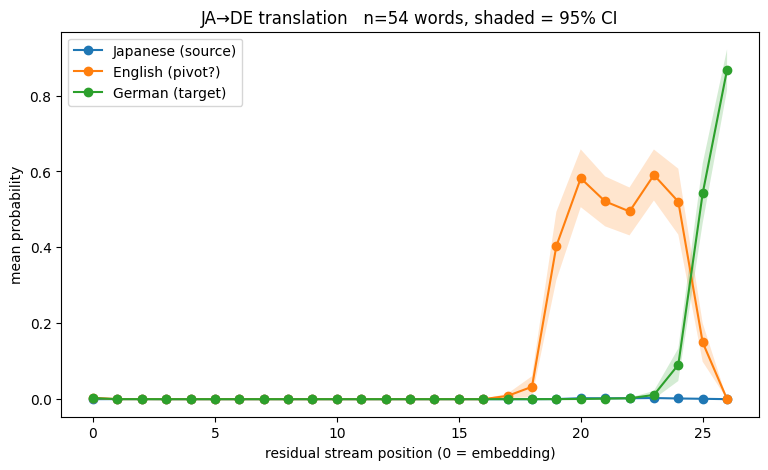

peak P(English) = 0.5907 ± 0.0672 at 23_pre (row 23)


In [16]:
curves_tr, widx_tr, labels = sweep(make_prompt)
np.save(OUT / "curves_translation.npy", curves_tr)
np.save(OUT / "widx_translation.npy",   widx_tr)
mean_tr, ci_tr = plot_curves(curves_tr, widx_tr, labels,
                             "JA→DE translation", OUT / "fig_translation.png")

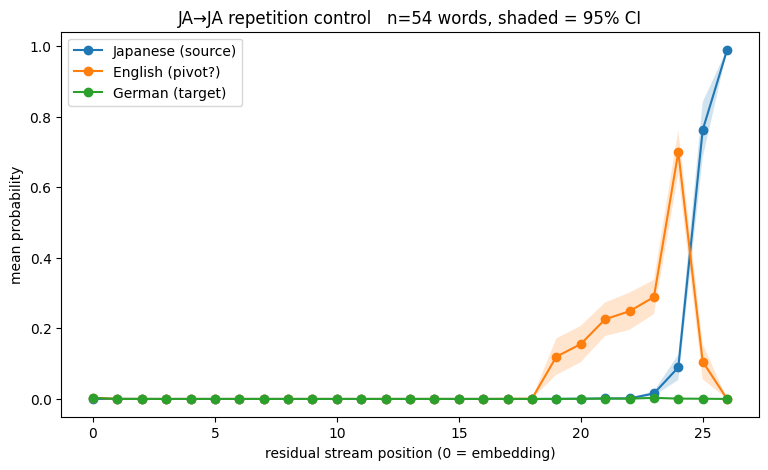

peak P(English) = 0.6997 ± 0.0619 at 24_pre (row 24)


In [17]:
curves_ct, widx_ct, labels = sweep(make_repeat_prompt)
np.save(OUT / "curves_control.npy", curves_ct)
np.save(OUT / "widx_control.npy",   widx_ct)
mean_ct, ci_ct = plot_curves(curves_ct, widx_ct, labels,
                             "JA→JA repetition control", OUT / "fig_control.png")

In [18]:
print(f"{'condition':<24}{'peak P(EN)':>12}{'±95% CI':>10}{'position':>12}")
for name, m, c in [("JA→DE translation", mean_tr, ci_tr),
                   ("JA→JA repetition",  mean_ct, ci_ct)]:
    i = int(m[:, 1].argmax())
    print(f"{name:<24}{m[i,1]:>12.4f}{c[i,1]:>10.4f}{labels[i]:>12}")

condition                 peak P(EN)   ±95% CI    position
JA→DE translation             0.5907    0.0672      23_pre
JA→JA repetition              0.6997    0.0619      24_pre


In [19]:
rng = np.random.default_rng(0)

def peak_en(curves, word_idx, pick):
    """Mean peak P(English) over a bootstrap resample of words."""
    words = np.unique(word_idx)
    pw = np.stack([curves[word_idx == words[i]].mean(0) for i in pick])
    return pw.mean(0)[:, 1].max()

n_words = len(np.unique(widx_tr))
full    = np.arange(n_words)
obs     = peak_en(curves_tr, widx_tr, full) - peak_en(curves_ct, widx_ct, full)

boot = np.array([
    peak_en(curves_tr, widx_tr, idx) - peak_en(curves_ct, widx_ct, idx)
    for idx in (rng.integers(0, n_words, n_words) for _ in range(2000))
])
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"Δ peak P(English), translation − repetition = {obs:+.4f}")
print(f"95% bootstrap CI over {n_words} words: [{lo:+.4f}, {hi:+.4f}]")
print("→ conditions separate" if (lo > 0 or hi < 0)
      else f"→ cannot resolve a difference at n={n_words}")

Δ peak P(English), translation − repetition = -0.1090
95% bootstrap CI over 54 words: [-0.1494, -0.0563]
→ conditions separate


## Send results back to VS Code

The kernel is remote, so `np.save()` writes to the GPU container and nothing
here can read it. Instead the arrays ride back inside the notebook's own
output as base64 — the `.ipynb` is a local file, so anything printed into it
has already arrived.

After running this cell, decode it locally:

```
python extract_results.py
```

That writes `results/*.npy` and pulls the embedded figures out to
`results/*.png`. No Kaggle filesystem, no downloads, no git.

In [20]:
# Emit results back through the notebook's OWN OUTPUT, not the kernel's disk.
#
# The kernel runs on a remote GPU, so anything np.save() writes lands in that
# container and dies with it. The one channel that reaches VS Code is the
# notebook output itself -- which is a local file. So the arrays are packed
# into an npz, base64'd, and printed. Run extract_results.py here afterwards
# to decode them into results/. Figures need no help: matplotlib embeds them
# in the notebook automatically, and the same script pulls those out too.
import base64, io
import numpy as np

ARRAYS = dict(
    curves_translation=curves_tr, widx_translation=widx_tr,
    curves_control=curves_ct,     widx_control=widx_ct,
)

buf = io.BytesIO()
np.savez_compressed(buf, **ARRAYS)
raw = buf.getvalue()
b64 = base64.b64encode(raw).decode()

print(f"#RESULTS_NPZ_B64# {len(ARRAYS)} arrays, {len(raw)/1024:.1f} KB packed")
for i in range(0, len(b64), 4000):        # chunked: avoids any single-line limits
    print(b64[i:i + 4000])
print("#END_RESULTS_NPZ_B64#")
print()
print("Now run, in the VS Code terminal:   python extract_results.py")

#RESULTS_NPZ_B64# 4 arrays, 98.5 KB packed
...
#END_RESULTS_NPZ_B64#

Now run, in the VS Code terminal:   python extract_results.py
